In [1]:
import pandas as pd
import json
from pathlib import Path

data_dir = Path("../data")
output_dir = Path("../output")

print("RQ4 setup complete.")

RQ4 setup complete.


In [2]:
# Load the pull request dataset

pr_df = pd.read_parquet(data_dir / "top5_languages_prs.parquet")

print(f"Number of PRs loaded: {len(pr_df):,}")
print("\nLanguages:")
print(pr_df["language_analysis"].value_counts())

Number of PRs loaded: 27,853

Languages:
language_analysis
go            10108
typescript     7490
python         7191
csharp         1985
rust           1079
Name: count, dtype: int64


In [3]:
# Keep only the four languages used in the final study

final_languages = ["go", "typescript", "python", "csharp"]

pr_df = pr_df[
    pr_df["language_analysis"].isin(final_languages)
].copy()

print(f"PRs after filtering: {len(pr_df):,}")

print("\nLanguages included:")
print(pr_df["language_analysis"].value_counts())

PRs after filtering: 26,774

Languages included:
language_analysis
go            10108
typescript     7490
python         7191
csharp         1985
Name: count, dtype: int64


In [4]:
# Create merge status

pr_df["merge_status"] = pr_df["merged_at"].apply(
    lambda x: "Merged" if pd.notna(x) else "Unmerged"
)

print("PRs by merge status:")
print(pr_df["merge_status"].value_counts())

print("\nPercentages:")
print(
    pr_df["merge_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

PRs by merge status:
merge_status
Merged      19403
Unmerged     7371
Name: count, dtype: int64

Percentages:
merge_status
Merged      72.47
Unmerged    27.53
Name: proportion, dtype: float64


In [5]:
# Load library analysis results for the final four languages

languages = ["python", "typescript", "go", "csharp"]

all_records = []

for language in languages:
    file_path = output_dir / f"{language}_library_usage.json"

    with open(file_path, "r", encoding="utf-8") as f:
        records = json.load(f)

    all_records.extend(records)

library_df = pd.DataFrame(all_records)

print(f"Library analysis records: {len(library_df):,}")

print("\nRecords by language:")
print(library_df["language"].value_counts())

Library analysis records: 26,760

Records by language:
language
go            10107
typescript     7480
python         7190
csharp         1983
Name: count, dtype: int64


In [6]:
# Merge library analysis with PR merge status

rq4_df = library_df.merge(
    pr_df[["id", "merge_status"]],
    left_on="pr_id",
    right_on="id",
    how="left"
)

rq4_df = rq4_df.drop(columns=["id"])

print(f"Final RQ4 records: {len(rq4_df):,}")

print("\nMerge status counts:")
print(rq4_df["merge_status"].value_counts(dropna=False))

Final RQ4 records: 26,760

Merge status counts:
merge_status
Merged      19403
Unmerged     7357
Name: count, dtype: int64


In [7]:
# Create library-usage indicators

rq4_df["uses_stdlib"] = rq4_df["stdlib_imports"].apply(
    lambda x: len(x) > 0
)

rq4_df["uses_extlib"] = rq4_df["extlib_imports"].apply(
    lambda x: len(x) > 0
)

rq4_df["uses_any_library"] = (
    rq4_df["uses_stdlib"] | rq4_df["uses_extlib"]
)

rq4_df["adds_dependency"] = (
    rq4_df["dep_no_version"].apply(lambda x: len(x) > 0)
    | rq4_df["dep_with_version"].apply(lambda x: len(x) > 0)
)

rq4_df[
    [
        "pr_id",
        "merge_status",
        "uses_stdlib",
        "uses_extlib",
        "uses_any_library",
        "adds_dependency"
    ]
].head()

,pr_id,merge_status,uses_stdlib,uses_extlib,uses_any_library,adds_dependency
0,2756921963,Unmerged,True,True,True,False
1,2758200405,Unmerged,True,False,True,False
2,2760044965,Unmerged,False,False,False,False
3,2760243902,Merged,True,True,True,False
4,2761264439,Merged,False,False,False,False


In [8]:
# Calculate overall RQ4 summary

rq4_summary = rq4_df.groupby("merge_status").agg(
    total_prs=("pr_id", "count"),
    any_library_pct=("uses_any_library", lambda x: x.mean() * 100),
    stdlib_pct=("uses_stdlib", lambda x: x.mean() * 100),
    extlib_pct=("uses_extlib", lambda x: x.mean() * 100),
    new_dependency_pct=("adds_dependency", lambda x: x.mean() * 100)
)

rq4_summary = rq4_summary.round(2)

rq4_summary

,total_prs,any_library_pct,stdlib_pct,extlib_pct,new_dependency_pct
merge_status,,,,,
Merged,19403,24.47,16.79,16.36,1.02
Unmerged,7357,42.68,26.41,36.01,2.00


In [9]:
# Calculate RQ4 results by programming language

rq4_by_language = rq4_df.groupby(
    ["language", "merge_status"]
).agg(
    total_prs=("pr_id", "count"),
    any_library_pct=("uses_any_library", lambda x: x.mean() * 100),
    stdlib_pct=("uses_stdlib", lambda x: x.mean() * 100),
    extlib_pct=("uses_extlib", lambda x: x.mean() * 100),
    new_dependency_pct=("adds_dependency", lambda x: x.mean() * 100)
)

rq4_by_language = rq4_by_language.round(2)

rq4_by_language

total_prs  any_library_pct  stdlib_pct  extlib_pct  \
language   merge_status                                                       
csharp     Merged             1146            40.75       32.64       34.21   
           Unmerged            837            51.97       44.09       41.34   
go         Merged             8361            10.98       10.73        2.06   
           Unmerged           1746            20.33       19.87        8.71   
python     Merged             5468            32.33       28.46       19.82   
           Unmerged           1722            55.28       48.14       48.20   
typescript Merged             4428            36.02        9.71       34.46   
           Unmerged           3052            45.81       13.04       43.28   

                         new_dependency_pct  
language   merge_status                      
csharp     Merged                      4.89  
           Unmerged                    7.65  
go         Merged                      0.06  
           Unmerged                    0.63  
python     Merged                      2.40  
           Unmerged                    4.01  
typescript Merged                      0.14  
           Unmerged                    0.10

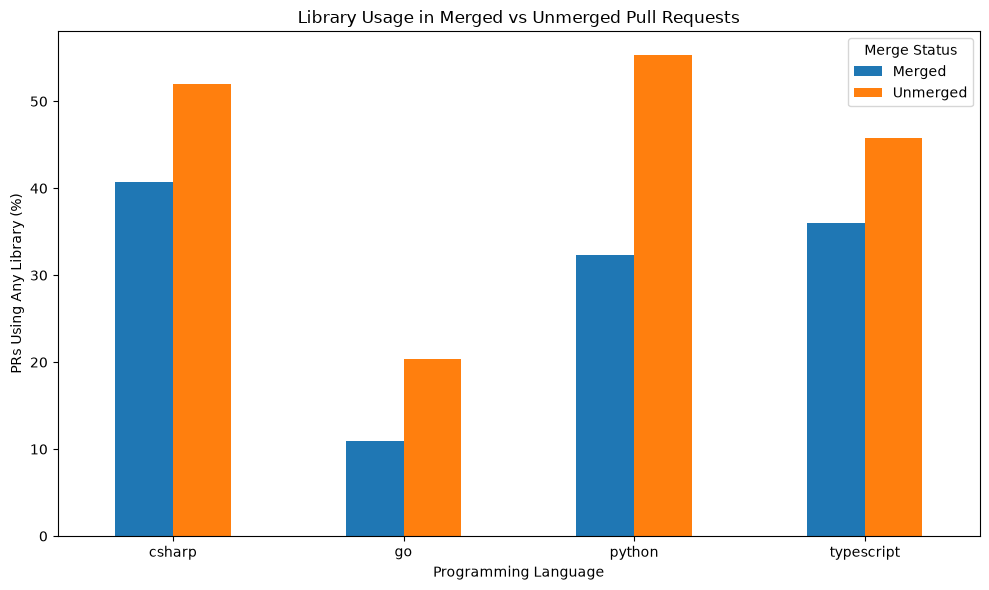

In [10]:
import matplotlib.pyplot as plt

# Prepare data for graph
plot_data = rq4_by_language["any_library_pct"].unstack()

# Create bar chart
ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Programming Language")
ax.set_ylabel("PRs Using Any Library (%)")
ax.set_title("Library Usage in Merged vs Unmerged Pull Requests")
ax.legend(title="Merge Status")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

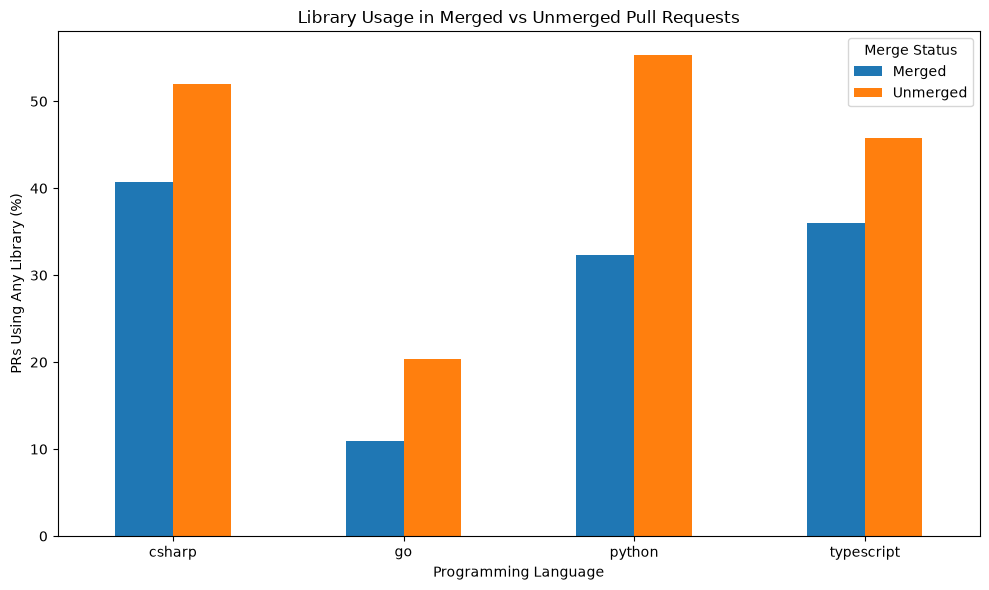

RQ4 graph saved to: ..\output\rq4_merged_vs_unmerged_by_language.png


In [11]:
# Save the RQ4 graph

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Programming Language")
ax.set_ylabel("PRs Using Any Library (%)")
ax.set_title("Library Usage in Merged vs Unmerged Pull Requests")
ax.legend(title="Merge Status")

plt.xticks(rotation=0)
plt.tight_layout()

graph_path = output_dir / "rq4_merged_vs_unmerged_by_language.png"

plt.savefig(graph_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"RQ4 graph saved to: {graph_path}")

In [12]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    rq4_df["merge_status"],
    rq4_df["uses_any_library"]
)

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:")
print(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Contingency Table:
uses_any_library  False  True 
merge_status                  
Merged            14655   4748
Unmerged           4217   3140

Chi-square statistic: 850.0481
P-value: 0.000000
Degrees of freedom: 1


In [13]:
import numpy as np

# Calculate Cramer's V effect size

n = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * min(contingency_table.shape[0] - 1,
                    contingency_table.shape[1] - 1))
)

print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.1782


In [14]:
# Save corrected RQ4 results

rq4_summary.to_csv(
    output_dir / "rq4_merged_vs_unmerged_summary.csv"
)

rq4_by_language.to_csv(
    output_dir / "rq4_by_language.csv"
)

statistical_results = pd.DataFrame({
    "chi_square": [chi2],
    "p_value": [p_value],
    "degrees_of_freedom": [dof],
    "cramers_v": [cramers_v]
})

statistical_results.to_csv(
    output_dir / "rq4_statistical_results.csv",
    index=False
)

print("RQ4 result tables saved successfully.")

RQ4 result tables saved successfully.


In [15]:
print("=" * 60)
print("FINAL RQ4 VERIFICATION")
print("=" * 60)

print(f"\nTotal RQ4 PRs: {len(rq4_df):,}")

print("\nLanguages:")
print(rq4_df["language"].value_counts())

print("\nMerge Status:")
print(rq4_df["merge_status"].value_counts())

print("\nOverall RQ4 Results:")
print(rq4_summary)

print("\nStatistical Results:")
print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Cramer's V: {cramers_v:.4f}")

print("\nOutput Files:")
files = [
    "rq4_merged_vs_unmerged_summary.csv",
    "rq4_by_language.csv",
    "rq4_merged_vs_unmerged_by_language.png",
    "rq4_statistical_results.csv"
]

for file in files:
    path = output_dir / file
    print(f"{'✓' if path.exists() else '✗'} {file}")

FINAL RQ4 VERIFICATION

Total RQ4 PRs: 26,760

Languages:
language
go            10107
typescript     7480
python         7190
csharp         1983
Name: count, dtype: int64

Merge Status:
merge_status
Merged      19403
Unmerged     7357
Name: count, dtype: int64

Overall RQ4 Results:
              total_prs  any_library_pct  stdlib_pct  extlib_pct  \
merge_status                                                       
Merged            19403            24.47       16.79       16.36   
Unmerged           7357            42.68       26.41       36.01   

              new_dependency_pct  
merge_status                      
Merged                      1.02  
Unmerged                    2.00  

Statistical Results:
Chi-square: 850.0481
P-value: 0.000000
Cramer's V: 0.1782

Output Files:
✓ rq4_merged_vs_unmerged_summary.csv
✓ rq4_by_language.csv
✓ rq4_merged_vs_unmerged_by_language.png
✓ rq4_statistical_results.csv
